In [12]:
# P 1.1
import numpy as np  
import sys
print(sys.executable)

/home/jack/miniconda3/envs/aa276_hw1/bin/python


In [16]:
# import jax
# import jax.numpy as jnp
# import numpy as np
# from IPython.display import HTML
# import matplotlib.animation as anim
# import matplotlib.pyplot as plt
# import plotly.graph_objects as go

# import hj_reachability as hj

############################### another version of the value function
import jax
import jax.numpy as jnp
import numpy as np
import hj_reachability as hj

from hj_reachability import dynamics
from hj_reachability import sets
from tqdm import tqdm

In [17]:
# class InvertedPendulum(hj.ControlAndDisturbanceAffineDynamics):
#     def __init__(
#         self,
#         m=2.0,
#         l=1.0,
#         g=10.0,
#         u_max=3.0,
#         control_mode="max",      
#         disturbance_mode="min"
#     ):
#         self.m = m
#         self.l = l
#         self.g = g

#         control_space = hj.sets.Box(
#             jnp.array([-u_max]),
#             jnp.array([ u_max])
#         )

#         # No disturbance in my model.
#         disturbance_space = hj.sets.Box(
#             jnp.array([0.0]),
#             jnp.array([0.0])
#         )
        
#         super().__init__(
#             control_mode=control_mode,
#             disturbance_mode=disturbance_mode,
#             control_space=control_space,
#             disturbance_space=disturbance_space,
#         )

#     def open_loop_dynamics(self, state, time):
#         theta, omega = state
#         return jnp.array([
#             omega,
#             (self.g / self.l) * jnp.sin(theta)
#         ])

#     def control_jacobian(self, state, time):
#         return jnp.array([
#             [0.0],
#             [1.0 / (self.m * self.l**2)]
#         ])

#     def disturbance_jacobian(self, state, time):
#         return jnp.array([
#             [0.0],
#             [0.0]
#         ])


class InvertedPendulum(dynamics.ControlAndDisturbanceAffineDynamics):

  def __init__(self,
               m=2.0,
               l=1.0,
               g=10.0,
               u_max=3.0):
    self.m = m
    self.l = l
    self.g = g

    # Controller chooses torque u in [-3, 3].
    # For a backward reachable tube of the failure set, use control_mode='max'
    # to compute the best-case controlled safety value.
    control_mode = "max"
    disturbance_mode = "min"

    control_space = sets.Box(
        jnp.array([-u_max]),
        jnp.array([+u_max])
    )

    # No disturbance in this problem.
    disturbance_space = sets.Box(
        jnp.array([0.0]),
        jnp.array([0.0])
    )

    super().__init__(
        control_mode,
        disturbance_mode,
        control_space,
        disturbance_space
    )

  def open_loop_dynamics(self, state, time):
    theta, theta_dot = state

    return jnp.array([
        theta_dot,
        (self.g / self.l) * jnp.sin(theta)
    ])

  def control_jacobian(self, state, time):
    return jnp.array([
        [0.0],
        [1.0 / (self.m * self.l ** 2)]
    ])

  def disturbance_jacobian(self, state, time):
    return jnp.array([
        [0.0],
        [0.0]
    ])

In [26]:
# dynamics = InvertedPendulum(
#     m=2.0,
#     l=1.0,
#     g=10.0,
#     u_max=3.0,
#     control_mode="max"  
# )

# grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
#     hj.sets.Box(
#         lo=np.array([-np.pi, -10.0]),
#         hi=np.array([ np.pi,  10.0])
#     ),
#     (101, 101),
#     periodic_dims=0   # theta is periodic
# )

grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    hj.sets.Box(
        np.array([-np.pi, -10.0]),
        np.array([+np.pi, +10.0])
    ),
    (101, 101)
)

values = 0.3 - jnp.abs(grid.states[..., 0])
# failure_values = jnp.abs(grid.states[..., 0]) - 0.3

solver_settings = hj.SolverSettings.with_accuracy("very_high", hamiltonian_postprocessor=hj.solver.backwards_reachable_tube)

In [27]:
times = np.linspace(0, -5, 101)

# Problem parameters
m = 2.0       # kg
l = 1.0       # m
g = 10.0      # m / s^2
u_max = 3.0   # torque bound

pendulum_dynamics = InvertedPendulum(m=m, l=l, g=g, u_max=u_max)

# initial_values = values
# all_values = hj.solve(solver_settings, dynamics, grid, times, initial_values)
all_values = hj.solve(solver_settings, pendulum_dynamics, grid, times, values)

100%|##########|  5.0000/5.0 [00:05<00:00,  1.03s/sim_s]


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
m = 2.0
l = 1.0
g = 10.0

u_min = -3.0
u_max = 3.0


In [29]:
#Helpers  

def wrap_theta(theta):
    return (theta + np.pi) % (2 * np.pi) - np.pi


def pendulum_dynamics(x, u):
    theta, omega = x
    return np.array([
        omega,
        (g / l) * np.sin(theta) + u / (m * l**2)
    ])

##############
def pendulum_dynamics_disturbed(x, u, d):

    theta, omega = x

    return np.array([
        omega + d,
        (g / l) * np.sin(theta) + u / (m * l**2)
    ])
######################

def u_nominal(x, t):

    theta, omega = x

    if 0.0 <= t < 1.0:
        u = 3.0
    elif 1.0 <= t < 2.0:
        u = -3.0
    elif 2.0 <= t < 3.0:
        u = 3.0
    else:
        u = m * l**2 * (
            -(g / l) * np.sin(theta)
            - 1.5 * theta
            - 1.5 * omega
        )
    return np.clip(u, u_min, u_max)

In [30]:
# V values and DV
V_star = np.array(all_values[-1])

grads_star = grid.grad_values(V_star, solver_settings.upwind_scheme)
grads_star = np.array(grads_star)

# beta2 = dV / d omega
beta2s = grads_star[:, :, 1]

theta_vec = np.array(grid.coordinate_vectors[0])
omega_vec = np.array(grid.coordinate_vectors[1])

V_interpolator = RegularGridInterpolator(
    (theta_vec, omega_vec),
    V_star,
    bounds_error=False,
    fill_value=None
)

beta2_interpolator = RegularGridInterpolator(
    (theta_vec, omega_vec),
    beta2s,
    bounds_error=False,
    fill_value=None
)

def value_function(x):

    theta, omega = x
    x_query = np.array([wrap_theta(theta), omega])
    return V_interpolator(x_query).item()

def optimal_safety_controller(x):

    theta, omega = x
    x_query = np.array([wrap_theta(theta), omega])

    beta2 = beta2_interpolator(x_query).item()

    if beta2 > 0:
        return u_max
    elif beta2 < 0:
        return u_min
    else:
        return 0.0
    
def least_restrictive_filter(x, t):

    Vx = value_function(x)

    if Vx > 0.0:
        return u_nominal(x, t)
    else:
        return optimal_safety_controller(x)

In [31]:
# Simulation
def simulate_least_restrictive(x0, T=5.0, dt=0.01):
    nt = int(round(T / dt)) + 1
    ts = np.linspace(0.0, T, nt)

    xs = np.zeros((nt, 2))
    us_lr = np.zeros(nt - 1)
    us_nom = np.zeros(nt - 1)
    Vs = np.zeros(nt)

    xs[0] = np.array(x0, dtype=float)
    xs[0, 0] = wrap_theta(xs[0, 0])
    Vs[0] = value_function(xs[0])

    for k in range(nt - 1):
        t = ts[k]
        x = xs[k]

        u_nom = u_nominal(x, t)
        u_lr = least_restrictive_filter(x, t)

        us_nom[k] = u_nom
        us_lr[k] = u_lr

        # Euler integration
        xs[k + 1] = x + dt * pendulum_dynamics(x, u_lr)
        # d = np.random.uniform(0.0, 0.4)
        # xs[k + 1] = x + dt * pendulum_dynamics_disturbed(x, u_lr, d)
        xs[k + 1, 0] = wrap_theta(xs[k + 1, 0])

        Vs[k + 1] = value_function(xs[k + 1])

    return ts, xs, us_lr, us_nom, Vs

x0_1 = np.array([0.0, 0.0])
x0_2 = np.array([0.05, 0.05])

ts1, xs1, us1_lr, us1_nom, Vs1 = simulate_least_restrictive(x0_1, T=5.0, dt=0.01)
ts2, xs2, us2_lr, us2_nom, Vs2 = simulate_least_restrictive(x0_2, T=5.0, dt=0.01)

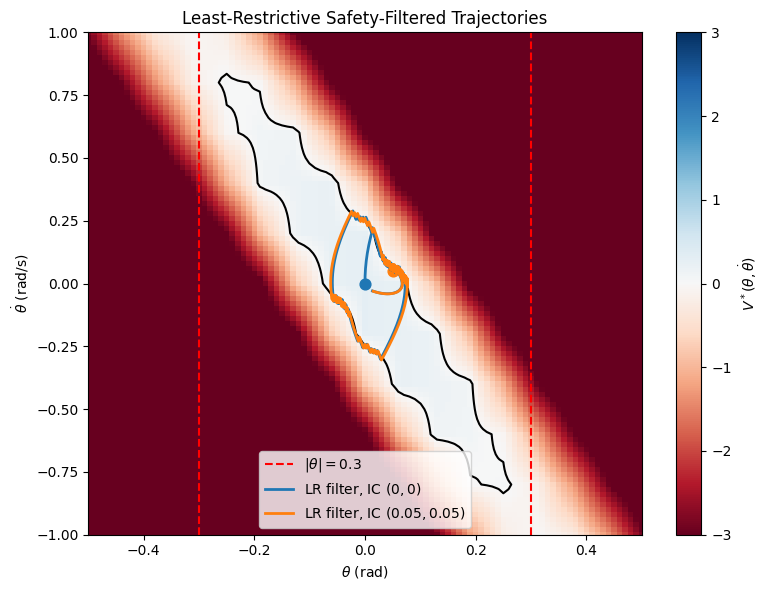

In [32]:
# Plotting
# plt.figure(figsize=(8, 6))

# vbar = np.max(np.abs(V_star))

# plt.pcolormesh(
#     theta_vec,
#     omega_vec,
#     V_star.T,
#     shading="auto",
#     cmap="RdBu",
#     vmin=-vbar,
#     vmax=+vbar
# )
# plt.colorbar(label=r"$V^*(\theta,\dot{\theta})$")

# plt.contour(
#     theta_vec,
#     omega_vec,
#     V_star.T,
#     levels=[0],
#     colors="k",
#     linewidths=2
# )

# # Failure set boundary: |theta| = 0.3
# plt.axvline(-0.3, color="r", linestyle="--", linewidth=1.5, label=r"$|\theta|=0.3$")
# plt.axvline(0.3, color="r", linestyle="--", linewidth=1.5)

# plt.plot(xs1[:, 0], xs1[:, 1], linewidth=2, label=r"LR filter, IC $(0,0)$")
# plt.plot(xs2[:, 0], xs2[:, 1], linewidth=2, label=r"LR filter, IC $(0.05,0.05)$")

# plt.scatter(xs1[0, 0], xs1[0, 1], marker="o", s=60)
# plt.scatter(xs2[0, 0], xs2[0, 1], marker="o", s=60)

# plt.xlabel(r"$\theta$ (rad)")
# plt.ylabel(r"$\dot{\theta}$ (rad/s)")
# plt.title("Least-Restrictive Safety-Filtered Trajectories")
# plt.xlim([-0.5, 0.5])
# plt.ylim([-1.0, 1.0])
# plt.legend()
# plt.tight_layout()
# plt.show()

### Using helper functions

from problem1_helper import plot_value_and_safe_set_boundary

V_star = np.array(all_values[-1])

fig, ax = plt.subplots(figsize=(8, 6))

# Use provided helper function
plot_value_and_safe_set_boundary(V_star, grid, ax)

# Add colorbar
fig.colorbar(ax.collections[0], ax=ax, label=r"$V^*(\theta,\dot{\theta})$")

# Failure set boundary: |theta| = 0.3
ax.axvline(
    -0.3,
    color="r",
    linestyle="--",
    linewidth=1.5,
    label=r"$|\theta|=0.3$"
)
ax.axvline(
    0.3,
    color="r",
    linestyle="--",
    linewidth=1.5
)

# Plot trajectories
ax.plot(
    xs1[:, 0],
    xs1[:, 1],
    linewidth=2,
    label=r"LR filter, IC $(0,0)$"
)

ax.plot(
    xs2[:, 0],
    xs2[:, 1],
    linewidth=2,
    label=r"LR filter, IC $(0.05,0.05)$"
)

ax.scatter(xs1[0, 0], xs1[0, 1], marker="o", s=60)
ax.scatter(xs2[0, 0], xs2[0, 1], marker="o", s=60)

ax.set_xlabel(r"$\theta$ (rad)")
ax.set_ylabel(r"$\dot{\theta}$ (rad/s)")
ax.set_title("Least-Restrictive Safety-Filtered Trajectories")

ax.set_xlim([-0.5, 0.5])
ax.set_ylim([-1.0, 1.0])

ax.legend()
plt.tight_layout()
plt.show()

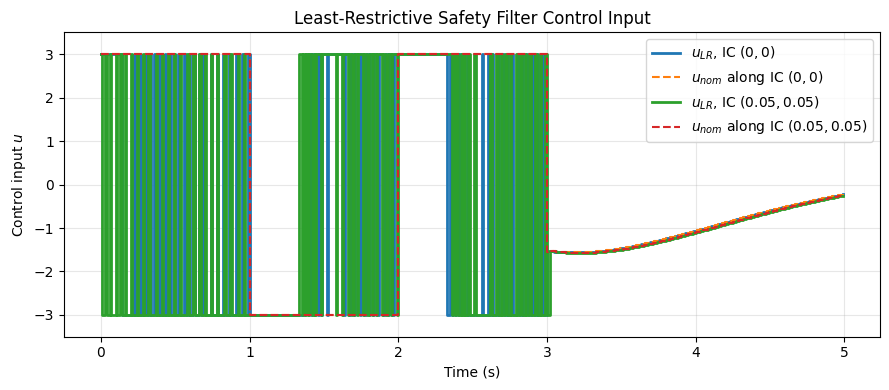

In [33]:
# Control Input Trajectories
plt.figure(figsize=(9, 4))

plt.step(
    ts1[:-1],
    us1_lr,
    where="post",
    linewidth=2,
    label=r"$u_{LR}$, IC $(0,0)$"
)
plt.step(
    ts1[:-1],
    us1_nom,
    where="post",
    linestyle="--",
    linewidth=1.5,
    label=r"$u_{nom}$ along IC $(0,0)$"
)

plt.step(
    ts2[:-1],
    us2_lr,
    where="post",
    linewidth=2,
    label=r"$u_{LR}$, IC $(0.05,0.05)$"
)
plt.step(
    ts2[:-1],
    us2_nom,
    where="post",
    linestyle="--",
    linewidth=1.5,
    label=r"$u_{nom}$ along IC $(0.05,0.05)$"
)

plt.xlabel("Time (s)")
plt.ylabel("Control input $u$")
plt.title("Least-Restrictive Safety Filter Control Input")
plt.ylim([-3.5, 3.5])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

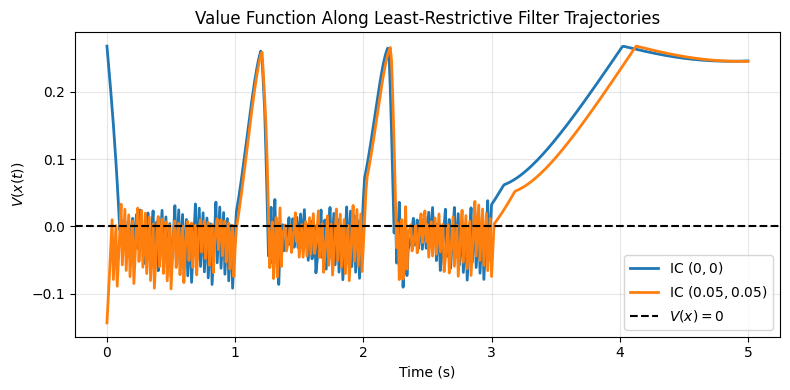

In [13]:
# ============================================================
# Plot V(x(t)) along trajectories
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(ts1, Vs1, linewidth=2, label=r"IC $(0,0)$")
plt.plot(ts2, Vs2, linewidth=2, label=r"IC $(0.05,0.05)$")

plt.axhline(0.0, color="k", linestyle="--", linewidth=1.5, label=r"$V(x)=0$")

plt.xlabel("Time (s)")
plt.ylabel(r"$V(x(t))$")
plt.title("Value Function Along Least-Restrictive Filter Trajectories")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# 1.2 
# Redo the converged value functions and gradients

V_star = np.array(all_values[-1])

grads_star = grid.grad_values(V_star, solver_settings.upwind_scheme)
grads_star = np.array(grads_star)

# grad V = [dV/dtheta, dV/domega]
beta1s = grads_star[:, :, 0]
beta2s = grads_star[:, :, 1]

theta_vec = np.array(grid.coordinate_vectors[0])
omega_vec = np.array(grid.coordinate_vectors[1])

V_interpolator = RegularGridInterpolator(
    (theta_vec, omega_vec),
    V_star,
    bounds_error=False,
    fill_value=None
)

beta1_interpolator = RegularGridInterpolator(
    (theta_vec, omega_vec),
    beta1s,
    bounds_error=False,
    fill_value=None
)

beta2_interpolator = RegularGridInterpolator(
    (theta_vec, omega_vec),
    beta2s,
    bounds_error=False,
    fill_value=None
)

def value_function(x):
    theta, omega = x
    x_query = np.array([wrap_theta(theta), omega])
    return V_interpolator(x_query).item()

def grad_value_function(x):
    theta, omega = x
    x_query = np.array([wrap_theta(theta), omega])
    beta1 = beta1_interpolator(x_query).item()
    beta2 = beta2_interpolator(x_query).item()
    return beta1, beta2

In [35]:

def qp_safety_controller(x, t):

    theta, omega = x
    u_nom = u_nominal(x, t)

    beta1, beta2 = grad_value_function(x)

    # Safety constraint:
    # beta1 * omega + beta2 * ((g/l) sin(theta) + u/(m l^2)) >= 0
    #
    # Rearranged:
    # a * u >= b
    a = beta2 / (m * l**2)
    b = -(beta1 * omega + beta2 * (g / l) * np.sin(theta))

    eps = 1e-8

    lo = u_min
    hi = u_max

    if a > eps:
        lo = max(lo, b / a)
    elif a < -eps:
        hi = min(hi, b / a)
    else:
        lhs_without_u = beta1 * omega + beta2 * (g / l) * np.sin(theta)
        if lhs_without_u < 0:
            return np.clip(u_nom, u_min, u_max)


    if lo > hi:
        return np.clip(u_nom, u_min, u_max)

    # Projection of u_nom onto feasible interval
    u_qp = np.clip(u_nom, lo, hi)
    return u_qp

In [36]:
def smooth_least_restrictive_filter(x, t):
    
    Vx = value_function(x)

    if Vx > 0.0:
        return u_nominal(x, t)
    else:
        return qp_safety_controller(x, t)

In [37]:
# sim
def simulate_smooth_lr(x0, T=5.0, dt=0.01):
    nt = int(round(T / dt)) + 1
    ts = np.linspace(0.0, T, nt)

    xs = np.zeros((nt, 2))
    us_slr = np.zeros(nt - 1)
    us_nom = np.zeros(nt - 1)
    Vs = np.zeros(nt)

    xs[0] = np.array(x0, dtype=float)
    xs[0, 0] = wrap_theta(xs[0, 0])
    Vs[0] = value_function(xs[0])

    for k in range(nt - 1):
        t = ts[k]
        x = xs[k]

        u_nom = u_nominal(x, t)
        u = smooth_least_restrictive_filter(x, t)

        us_nom[k] = u_nom
        us_slr[k] = u

        xs[k + 1] = x + dt * pendulum_dynamics(x, u)
        xs[k + 1, 0] = wrap_theta(xs[k + 1, 0])

        Vs[k + 1] = value_function(xs[k + 1])

    return ts, xs, us_slr, us_nom, Vs


x0_1 = np.array([0.0, 0.0])
x0_2 = np.array([0.05, 0.05])

ts1, xs1, us1_slr, us1_nom, Vs1 = simulate_smooth_lr(x0_1, T=5.0, dt=0.01)
ts2, xs2, us2_slr, us2_nom, Vs2 = simulate_smooth_lr(x0_2, T=5.0, dt=0.01)

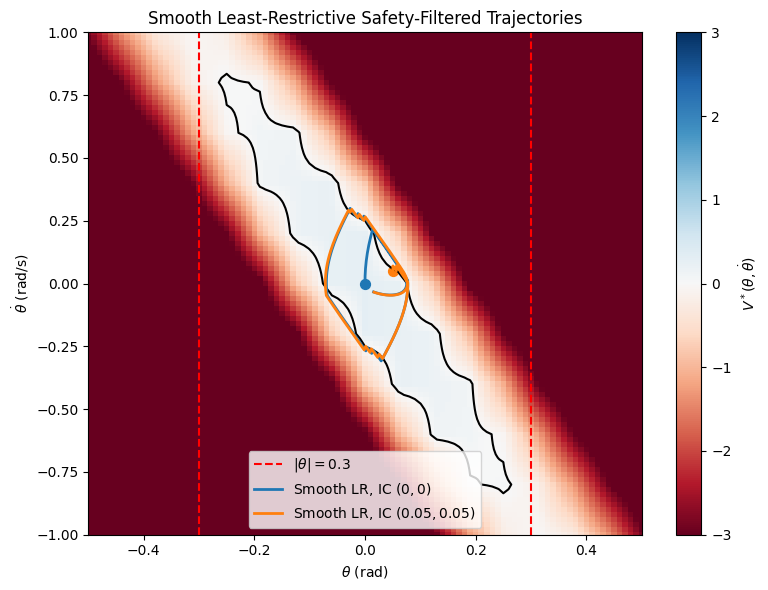

In [38]:
# Plotting the trajectories
# plt.figure(figsize=(8, 6))

# vbar = np.max(np.abs(V_star))

# plt.pcolormesh(
#     theta_vec,
#     omega_vec,
#     V_star.T,
#     shading="auto",
#     cmap="RdBu",
#     vmin=-vbar,
#     vmax=+vbar
# )
# plt.colorbar(label=r"$V^*(\theta,\dot{\theta})$")

# plt.contour(
#     theta_vec,
#     omega_vec,
#     V_star.T,
#     levels=[0],
#     colors="k",
#     linewidths=2
# )

# plt.axvline(-0.3, color="r", linestyle="--", linewidth=1.5, label=r"$|\theta|=0.3$")
# plt.axvline(0.3, color="r", linestyle="--", linewidth=1.5)

# plt.plot(xs1[:, 0], xs1[:, 1], linewidth=2, label=r"Smooth LR, IC $(0,0)$")
# plt.plot(xs2[:, 0], xs2[:, 1], linewidth=2, label=r"Smooth LR, IC $(0.05,0.05)$")

# plt.scatter(xs1[0, 0], xs1[0, 1], marker='o', s=50)
# plt.scatter(xs2[0, 0], xs2[0, 1], marker='o', s=50)

# plt.xlabel(r"$\theta$ (rad)")
# plt.ylabel(r"$\dot{\theta}$ (rad/s)")
# plt.title("Smooth Least-Restrictive Safety-Filtered Trajectories")
# plt.xlim([-0.5, 0.5])
# plt.ylim([-1.0, 1.0])
# plt.legend()
# plt.tight_layout()
# plt.show()


from problem1_helper import plot_value_and_safe_set_boundary

# converged value function
V_star = np.array(all_values[-1])

fig, ax = plt.subplots(figsize=(8, 6))

# Use the provided helper to draw the value function and V=0 boundary
plot_value_and_safe_set_boundary(V_star, grid, ax)

# Add colorbar for the pcolormesh produced inside the helper
fig.colorbar(ax.collections[0], ax=ax, label=r"$V^*(\theta,\dot{\theta})$")

# Failure set boundary: |theta| = 0.3
ax.axvline(-0.3, color="r", linestyle="--", linewidth=1.5, label=r"$|\theta|=0.3$")
ax.axvline(0.3, color="r", linestyle="--", linewidth=1.5)

# Plot trajectories
ax.plot(xs1[:, 0], xs1[:, 1], linewidth=2, label=r"Smooth LR, IC $(0,0)$")
ax.plot(xs2[:, 0], xs2[:, 1], linewidth=2, label=r"Smooth LR, IC $(0.05,0.05)$")

# Mark initial conditions
ax.scatter(xs1[0, 0], xs1[0, 1], marker='o', s=50)
ax.scatter(xs2[0, 0], xs2[0, 1], marker='o', s=50)

# Labels and formatting
ax.set_xlabel(r"$\theta$ (rad)")
ax.set_ylabel(r"$\dot{\theta}$ (rad/s)")
ax.set_title("Smooth Least-Restrictive Safety-Filtered Trajectories")
ax.set_xlim([-0.5, 0.5])
ax.set_ylim([-1.0, 1.0])

ax.legend()
plt.tight_layout()
plt.show()

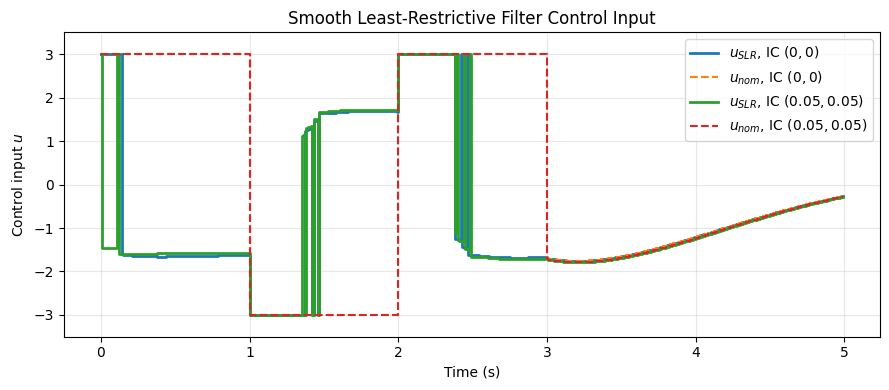

In [39]:
#Control Inputs
plt.figure(figsize=(9, 4))

plt.step(ts1[:-1], us1_slr, where="post", linewidth=2, label=r"$u_{SLR}$, IC $(0,0)$")
plt.step(ts1[:-1], us1_nom, where="post", linestyle="--", linewidth=1.5, label=r"$u_{nom}$, IC $(0,0)$")

plt.step(ts2[:-1], us2_slr, where="post", linewidth=2, label=r"$u_{SLR}$, IC $(0.05,0.05)$")
plt.step(ts2[:-1], us2_nom, where="post", linestyle="--", linewidth=1.5, label=r"$u_{nom}$, IC $(0.05,0.05)$")

plt.xlabel("Time (s)")
plt.ylabel("Control input $u$")
plt.title("Smooth Least-Restrictive Filter Control Input")
plt.ylim([-3.5, 3.5])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

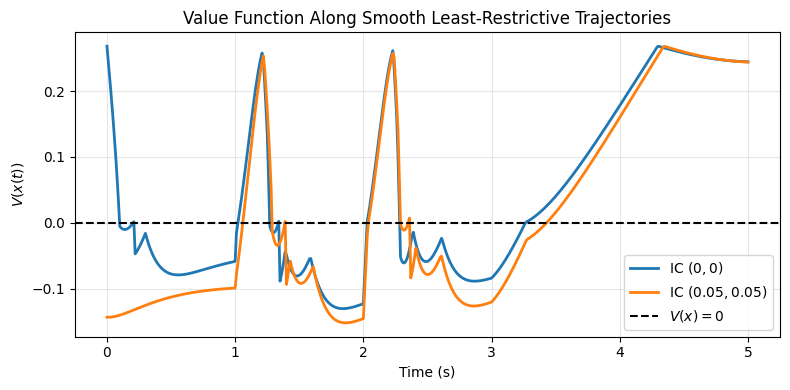

In [23]:
#Value function Over Time
plt.figure(figsize=(8, 4))

plt.plot(ts1, Vs1, linewidth=2, label=r"IC $(0,0)$")
plt.plot(ts2, Vs2, linewidth=2, label=r"IC $(0.05,0.05)$")
plt.axhline(0.0, color="k", linestyle="--", linewidth=1.5, label=r"$V(x)=0$")

plt.xlabel("Time (s)")
plt.ylabel(r"$V(x(t))$")
plt.title("Value Function Along Smooth Least-Restrictive Trajectories")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
# 1.3
GAMMA = 5.0# 0.0 , 0.5 , 5.0


In [53]:
def smooth_blending_filter(x, t, gamma=GAMMA):

    theta, omega = x

    u_nom = u_nominal(x, t)

    Vx = value_function(x)
    beta1, beta2 = grad_value_function(x)


    a = beta2 / (m * l**2)
    b = -(
        beta1 * omega
        + beta2 * (g / l) * np.sin(theta)
        + gamma * Vx
    )

    eps = 1e-8

    lo = u_min
    hi = u_max

    if a > eps:
        # a u >= b  ->  u >= b/a
        lo = max(lo, b / a)

    elif a < -eps:
        # a u >= b  ->  u <= b/a
        hi = min(hi, b / a)

    else:
        return np.clip(u_nom, u_min, u_max)

    if lo > hi:
        if a > 0:
            return u_max
        else:
            return u_min

    # Project u_nom onto the feasible interval
    u_sb = np.clip(u_nom, lo, hi)

    return u_sb

In [54]:
# sim
def simulate_smooth_blending(x0, gamma=GAMMA, T=5.0, dt=0.01):
    nt = int(round(T / dt)) + 1
    ts = np.linspace(0.0, T, nt)

    xs = np.zeros((nt, 2))
    us_sb = np.zeros(nt - 1)
    us_nom = np.zeros(nt - 1)
    Vs = np.zeros(nt)

    xs[0] = np.array(x0, dtype=float)
    xs[0, 0] = wrap_theta(xs[0, 0])
    Vs[0] = value_function(xs[0])

    for k in range(nt - 1):
        t = ts[k]
        x = xs[k]

        u_nom = u_nominal(x, t)
        u = smooth_blending_filter(x, t, gamma=gamma)

        us_nom[k] = u_nom
        us_sb[k] = u

        xs[k + 1] = x + dt * pendulum_dynamics(x, u)
        xs[k + 1, 0] = wrap_theta(xs[k + 1, 0])

        Vs[k + 1] = value_function(xs[k + 1])

    return ts, xs, us_sb, us_nom, Vs

x0_1 = np.array([0.0, 0.0])
x0_2 = np.array([0.05, 0.05])

ts1, xs1, us1_sb, us1_nom, Vs1 = simulate_smooth_blending(
    x0_1,
    gamma=GAMMA,
    T=5.0,
    dt=0.01
)

ts2, xs2, us2_sb, us2_nom, Vs2 = simulate_smooth_blending(
    x0_2,
    gamma=GAMMA,
    T=5.0,
    dt=0.01
)

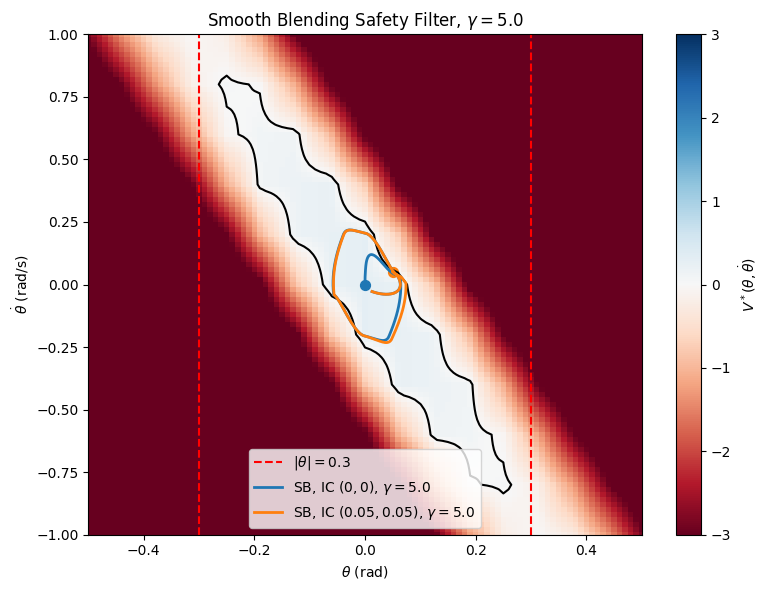

In [55]:
#Trajectory

# plt.figure(figsize=(8, 6))

# vbar = np.max(np.abs(V_star))

# plt.pcolormesh(
#     theta_vec,
#     omega_vec,
#     V_star.T,
#     shading="auto",
#     cmap="RdBu",
#     vmin=-vbar,
#     vmax=+vbar
# )
# plt.colorbar(label=r"$V^*(\theta,\dot{\theta})$")

# plt.contour(
#     theta_vec,
#     omega_vec,
#     V_star.T,
#     levels=[0],
#     colors="k",
#     linewidths=2
# )

# plt.axvline(-0.3, color="r", linestyle="--", linewidth=1.5, label=r"$|\theta|=0.3$")
# plt.axvline(0.3, color="r", linestyle="--", linewidth=1.5)

# plt.plot(xs1[:, 0], xs1[:, 1], linewidth=2, label=rf"SB, IC $(0,0)$, $\gamma={GAMMA}$")
# plt.plot(xs2[:, 0], xs2[:, 1], linewidth=2, label=rf"SB, IC $(0.05,0.05)$, $\gamma={GAMMA}$")

# plt.scatter(xs1[0, 0], xs1[0, 1], marker="o", s=50)
# plt.scatter(xs2[0, 0], xs2[0, 1], marker="o", s=50)

# plt.xlabel(r"$\theta$ (rad)")
# plt.ylabel(r"$\dot{\theta}$ (rad/s)")
# plt.title(rf"Smooth Blending Safety Filter, $\gamma={GAMMA}$")
# plt.xlim([-0.5, 0.5])
# plt.ylim([-1.0, 1.0])
# plt.legend()
# plt.tight_layout()
# plt.show()

# import numpy as np
# import matplotlib.pyplot as plt
from problem1_helper import plot_value_and_safe_set_boundary

# converged value function
V_star = np.array(all_values[-1])

fig, ax = plt.subplots(figsize=(8, 6))

# Use helper function to draw value function and V=0 boundary
plot_value_and_safe_set_boundary(V_star, grid, ax)

# Add colorbar for the pcolormesh created inside the helper
fig.colorbar(ax.collections[0], ax=ax, label=r"$V^*(\theta,\dot{\theta})$")

# Failure set boundary: |theta| = 0.3
ax.axvline(-0.3, color="r", linestyle="--", linewidth=1.5, label=r"$|\theta|=0.3$")
ax.axvline(0.3, color="r", linestyle="--", linewidth=1.5)

# Plot trajectories
ax.plot(xs1[:, 0], xs1[:, 1], linewidth=2, label=rf"SB, IC $(0,0)$, $\gamma={GAMMA}$")
ax.plot(xs2[:, 0], xs2[:, 1], linewidth=2, label=rf"SB, IC $(0.05,0.05)$, $\gamma={GAMMA}$")

# Mark initial conditions
ax.scatter(xs1[0, 0], xs1[0, 1], marker="o", s=50)
ax.scatter(xs2[0, 0], xs2[0, 1], marker="o", s=50)

# Labels and formatting
ax.set_xlabel(r"$\theta$ (rad)")
ax.set_ylabel(r"$\dot{\theta}$ (rad/s)")
ax.set_title(rf"Smooth Blending Safety Filter, $\gamma={GAMMA}$")
ax.set_xlim([-0.5, 0.5])
ax.set_ylim([-1.0, 1.0])

ax.legend()
plt.tight_layout()
plt.show()

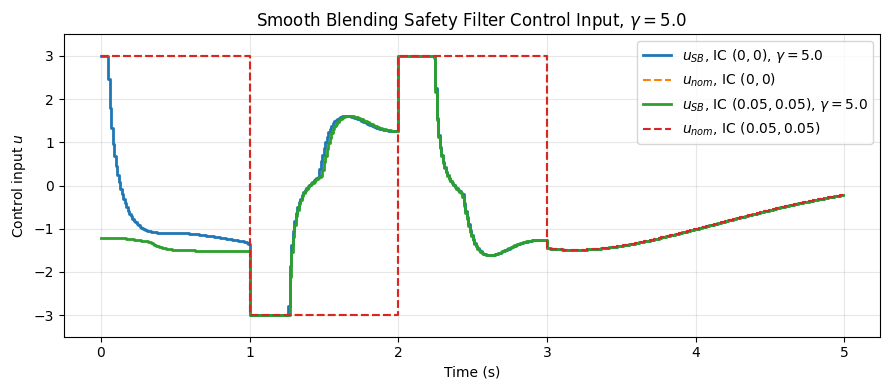

In [56]:
#Control Trajectories
plt.figure(figsize=(9, 4))

plt.step(
    ts1[:-1],
    us1_sb,
    where="post",
    linewidth=2,
    label=rf"$u_{{SB}}$, IC $(0,0)$, $\gamma={GAMMA}$"
)

plt.step(
    ts1[:-1],
    us1_nom,
    where="post",
    linestyle="--",
    linewidth=1.5,
    label=r"$u_{nom}$, IC $(0,0)$"
)

plt.step(
    ts2[:-1],
    us2_sb,
    where="post",
    linewidth=2,
    label=rf"$u_{{SB}}$, IC $(0.05,0.05)$, $\gamma={GAMMA}$"
)

plt.step(
    ts2[:-1],
    us2_nom,
    where="post",
    linestyle="--",
    linewidth=1.5,
    label=r"$u_{nom}$, IC $(0.05,0.05)$"
)

plt.xlabel("Time (s)")
plt.ylabel("Control input $u$")
plt.title(rf"Smooth Blending Safety Filter Control Input, $\gamma={GAMMA}$")
plt.ylim([-3.5, 3.5])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

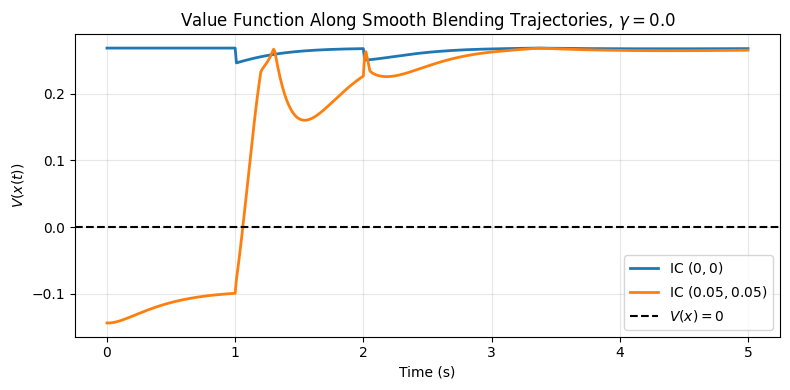

In [37]:
# Value Function Over Time

plt.figure(figsize=(8, 4))

plt.plot(ts1, Vs1, linewidth=2, label=r"IC $(0,0)$")
plt.plot(ts2, Vs2, linewidth=2, label=r"IC $(0.05,0.05)$")

plt.axhline(0.0, color="k", linestyle="--", linewidth=1.5, label=r"$V(x)=0$")

plt.xlabel("Time (s)")
plt.ylabel(r"$V(x(t))$")
plt.title(rf"Value Function Along Smooth Blending Trajectories, $\gamma={GAMMA}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()